# CSCI450 Project 1
## **Pill Counting**
This project implements a computer vision pipeline that is capable of detecting and counting medicinal pills in images. The goal is to analyze images containing different types of pills, varying in shape and color, placed at random orientations, and accurately determine the total number of pills present in a given image.

We synthesised our own dataset with different pill rotation and scaling for this project using real-world images of pills. The synthesised images are placed on a white appearing background which mimic photos taken by actual pill counting machines. The white background and the overall image have added noise to be more reflective of the potential real world application.

**Our Team:**

**- Lyudmyla Buhayenko**

**- Sergei Vorobev**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, feature, color, exposure, filters, morphology, measure
import os
from skimage.filters import gaussian, median, gabor
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import math
import pandas as pd
import seaborn as sn

### Normalization

In [2]:
def imNormalize(image):
    r = image[:,:,0]
    g = image[:,:,1]
    b = image[:,:,2]
    
    r = r - r.min()
    r = r / r.max()
    r = np.uint8(r * 255)
    
    g = g - g.min()
    g = g / g.max()
    g = np.uint8(g * 255)
    
    b = b - b.min()
    b = b / b.max()
    b = np.uint8(b * 255)
    
    return np.stack((r,g,b),axis=2) 

### Segmentation

In [3]:
def segment_pills(image, sigma=1, min_size=150, hole_size=50):
    gray = color.rgb2gray(image)
    smooth = gaussian(gray, sigma=sigma)
    smooth = median(smooth)

    threshold = filters.threshold_otsu(smooth)

    mask = smooth < threshold

    mask = morphology.remove_small_objects(mask, min_size=min_size)
    mask = morphology.remove_small_holes(mask, area_threshold=hole_size)
    #each pill gets different number
    labels = measure.label(mask)

    img_segmented = image.copy()
    img_segmented[~mask] = 0

    return img_segmented, mask, labels

In [4]:
#testing if working
img_00000 = io.imread("img_00000.png")
image_segmented, mask, labels = segment_pills(img_00000)

<Figure size 1500x500 with 0 Axes>

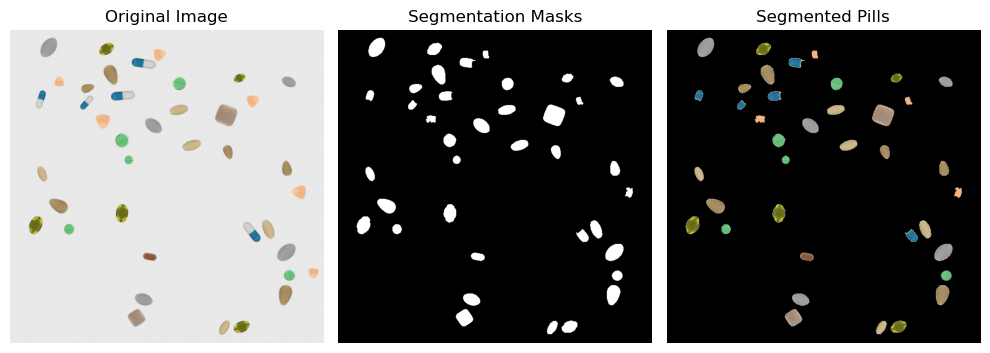

In [5]:
plt.figure(figsize=(15,5))

fig, (ax1, ax2, ax3) = plt.subplots(1,3,figsize = (10,5))
ax1.imshow(img_00000)
ax1.set_title('Original Image')
ax1.axis('off')

ax2.imshow(mask, cmap='gray')
ax2.set_title('Segmentation Masks')
ax2.axis('off')

ax3.imshow(image_segmented)
ax3.set_title('Segmented Pills')
ax3.axis('off')

plt.tight_layout()
plt.show()

### Load images from Dataset

In [6]:
path = '../pills_set/images'
imageList = sorted(os.listdir(path)) # keep consistency in case it reads it out of order

###  Defining Features

#### Histogram of Oriented Gradients (HOG)

In [7]:
def hog_features(image, orientations=9, pixels_per_cell=(16, 16),
                cells_per_block=(1, 1)):
        image = imNormalize(image)
        image = color.rgb2gray(image)

        hog_fd = feature.hog(image, orientations=orientations, pixels_per_cell=pixels_per_cell,
                    cells_per_block=cells_per_block)
        return hog_fd

#### Color Histograms

In [8]:
def colorHistogram(image):
    image = imNormalize(image)
    image = color.rgb2hsv(image)
    
    h1 = exposure.histogram(image[:,:,0])
    h2 = exposure.histogram(image[:,:,1])
    h3 = exposure.histogram(image[:,:,2])
    h = np.concatenate((h1[0],h2[0],h3[0]), axis = None)
    h = h / (image.shape[0]*image.shape[1])
    return h

#### Local Binary Patterns (LBP)

In [9]:
def lbp_features(image, radius = 1, n_points=8):
    image = imNormalize(image)
    image = color.rgb2gray(image)

    lbp = feature.local_binary_pattern(image, n_points, radius, method='uniform') 
    
    h = exposure.histogram(lbp, nbins=n_points + 2)
    h = h[0]

    h = h / (image.shape[0] * image.shape[1])

    return h


#### Gabor Filters

In [10]:
def gabor_filter(image, frequency=0.2, theta=0):
    image = imNormalize(image)
    image = color.rgb2gray(image)

    real, imag = filters.gabor(image, frequency=frequency, theta=theta)

    magnitude = np.sqrt(real**2 + imag**2)

    mean = magnitude.mean() #avg response
    std = magnitude.std()#variability of responses

    return np.array([mean, std])

#### DAISY

In [11]:
def daisy(image, step=8, radius=15, rings=2, histograms=6, orientations=8):
    image = imNormalize(image)
    image = color.rgb2gray(image)
    
    descs = feature.daisy(image, step=step, radius=radius, rings=rings, histograms=histograms,
                         orientations=orientations, visualize=False)

    # Returns a 1-d array which is more suitable for ML
    return descs.flatten()

### Extracting Features

Define function and extract features

In [12]:
def extract_features(image, hog_orientations=9, hog_pixels_per_cell=(16,16), 
                     lbp_radius=1, lbp_n_points=8,
                     gabor_frequency=0.2, gabor_theta=0,
                     daisy_step=8, daisy_radius=15, daisy_rings=2, daisy_histograms=6, daisy_orientations=8):
    
    fd_hog = hog_features(image, orientations=hog_orientations, pixels_per_cell=hog_pixels_per_cell)
    fd_colorHistogram = colorHistogram(image)
    fd_lbp = lbp_features(image, radius=lbp_radius, n_points=lbp_n_points)
    fd_gabor_filter = gabor_filter(image, frequency=gabor_frequency, theta=gabor_theta)
    fd_daisy = daisy(image, step=daisy_step, radius=daisy_radius, rings=daisy_rings, 
                     histograms=daisy_histograms, orientations=daisy_orientations)

    fd = np.concatenate([fd_hog, fd_lbp, fd_colorHistogram, fd_gabor_filter, fd_daisy])
    return fd

def extract_features_cached(imageList, path, save_path, hog_orientations=9, hog_pixels_per_cell=(16,16),
                            lbp_radius=1, lbp_n_points=8, gabor_frequency=0.2, gabor_theta=0,
                            daisy_step=8, daisy_radius=15, daisy_rings=2, daisy_histograms=6, daisy_orientations=8):
    if os.path.exists(save_path):
        return np.load(save_path)

    featuresize = len(extract_features(io.imread(path + '/' + imageList[0])))
    features = np.zeros((len(imageList), featuresize))
    for i in range(len(imageList)):
        image = io.imread(path + '/' + imageList[i])
        features[i,:] = extract_features(image, hog_orientations=hog_orientations, hog_pixels_per_cell=hog_pixels_per_cell,
                                         lbp_radius=lbp_radius, lbp_n_points=lbp_n_points,
                                         gabor_frequency=gabor_frequency, gabor_theta=gabor_theta,
                                         daisy_step=daisy_step, daisy_radius=daisy_radius, daisy_rings=daisy_rings,
                                         daisy_histograms=daisy_histograms, daisy_orientations=daisy_orientations)
        print('\rProcessing ' + str(i+1) + ' of ' + str(len(imageList)), end='')
    print("\nFeatures matrix shape: ", features.shape)
    np.save(save_path, features)
    return features

In [13]:
# # Custom script to parallelize feature extraction, remove before the final project submission
# from scripts.process_images import process_images_in_parallel
# from functools import partial
# num_processes = 16

# extract_v1 = partial(extract_features, 
#     hog_orientations=9, hog_pixels_per_cell=(8,8),
#     lbp_radius=1, lbp_n_points=8,
#     gabor_frequency=0.3, gabor_theta=0,
#     daisy_step=16, daisy_radius=10, daisy_rings=2, daisy_histograms=6, daisy_orientations=8)

# extract_v2 = partial(extract_features,
#     hog_orientations=9, hog_pixels_per_cell=(16,16),
#     lbp_radius=2, lbp_n_points=16,
#     gabor_frequency=0.2, gabor_theta=0,
#     daisy_step=32, daisy_radius=15, daisy_rings=3, daisy_histograms=8, daisy_orientations=8)

# extract_v3 = partial(extract_features,
#     hog_orientations=9, hog_pixels_per_cell=(32,32),
#     lbp_radius=3, lbp_n_points=24,
#     gabor_frequency=0.1, gabor_theta=0,
#     daisy_step=48, daisy_radius=20, daisy_rings=4, daisy_histograms=8, daisy_orientations=16)

# features_v1 = process_images_in_parallel(path, imageList, extract_v1, save_path='features/features_v1.npy')
# features_v2 = process_images_in_parallel(path, imageList, extract_v2, save_path='features/features_v2.npy')
# features_v3 = process_images_in_parallel(path, imageList, extract_v3, save_path='features/features_v3.npy')

In [14]:
features_v1 = extract_features_cached(imageList, path, 'features/features_v1.npy',
    hog_orientations=9, hog_pixels_per_cell=(8,8),
    lbp_radius=1, lbp_n_points=8, gabor_frequency=0.3, gabor_theta=0,
    daisy_step=16, daisy_radius=10, daisy_rings=2, daisy_histograms=6, daisy_orientations=8)

features_v2 = extract_features_cached(imageList, path, 'features/features_v2.npy',
    hog_orientations=9, hog_pixels_per_cell=(16,16),
    lbp_radius=2, lbp_n_points=16, gabor_frequency=0.2, gabor_theta=0,
    daisy_step=32, daisy_radius=15, daisy_rings=3, daisy_histograms=8, daisy_orientations=8)

features_v3 = extract_features_cached(imageList, path, 'features/features_v3.npy',
    hog_orientations=9, hog_pixels_per_cell=(32,32),
    lbp_radius=3, lbp_n_points=24, gabor_frequency=0.1, gabor_theta=0,
    daisy_step=48, daisy_radius=20, daisy_rings=4, daisy_histograms=8, daisy_orientations=16)

### Model Evaluation

In [15]:
def plot_feature_correlation(features):
    df = pd.DataFrame(features)
    plt.figure(figsize=(20, 15))
    dataplot = sn.heatmap(df.corr(), annot=True, cmap='coolwarm')
    plt.title('Correlation Matrix')
    plt.show()

def mean_absolute_error(actual, predicted):
    n = actual.shape[0]
    count = 0
    for i in range(n):
        count += abs(actual[i] - predicted[i])
    return count/n

def root_mean_squared_error(actual, predicted):
    n = actual.shape[0]
    count = 0
    for i in range(n):
        count += (actual[i] - predicted[i])**2
    return math.sqrt(count/n)

def model_prediction_correlation(actual, predicted):
    return np.corrcoef(actual,predited)[0,1]

def counting_prediction_accuracy(actual, predicted):
    total = actual.shape[0]
    count = 0
    for i in range(total):
        if round(predicted[i]) == actual[i]:
            count += 1
    return count/total

def evaluate_model(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = root_mean_squared_error(actual, predicted)
    r = model_prediction_correlation(actual, predicted)
    acc = counting_prediction_accuracy(actual, predicted)
    return (mae, rmse, r, acc)

### Defining X and Y

In [16]:
# X = features
# y = number of pills in each image

X = features_v1
y = []

for name in imageList:
    image = io.imread(path + '/' + name)

    segmented, mask, labels = segment_pills(image) #labels is different pills

    count = labels.max()

    y.append(count)
y = np.array(y)

print("y shape: ", y.shape)


KeyboardInterrupt: 

### Scaling Features

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Splitting data into training and testing set

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2)

## Simple linear regression counting

In [ ]:
plot_feature_correlation(features)